In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/Sample - Superstore.csv', encoding='cp1252')

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Task 1

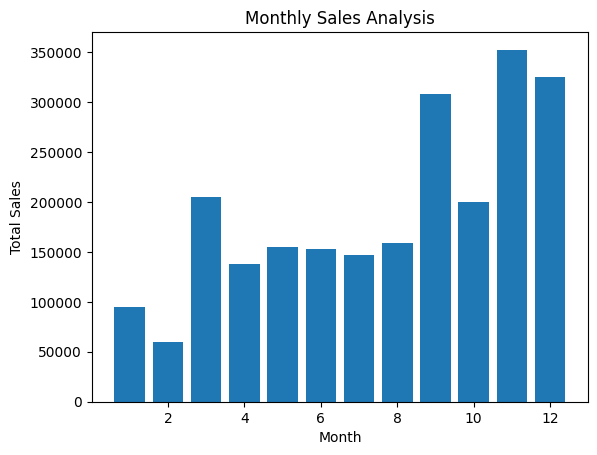

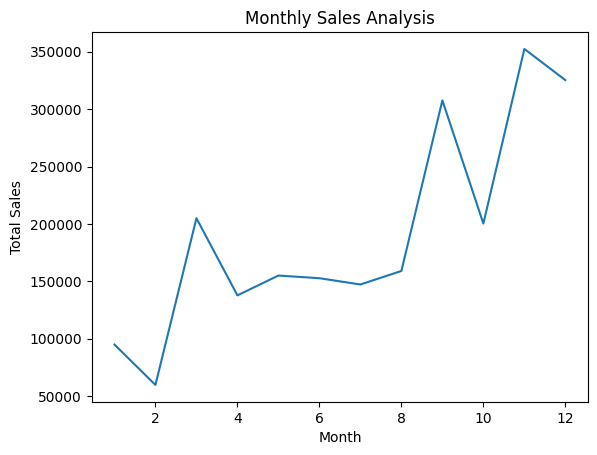

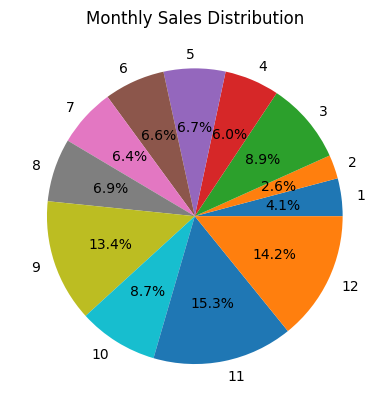

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Num'] = df['Order Date'].dt.month


monthly_sales = df.groupby('Month_Num')['Sales'].sum().reset_index()
monthly_sales.columns = ['Month_Num', 'Total_Sales']

plt.bar(monthly_sales['Month_Num'], monthly_sales['Total_Sales'])
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Analysis')
plt.show()


plt.plot(monthly_sales['Month_Num'], monthly_sales['Total_Sales'])
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Analysis')
plt.show()

plt.pie(monthly_sales['Total_Sales'], labels=monthly_sales['Month_Num'], autopct='%1.1f%%')
plt.title('Monthly Sales Distribution')
plt.show()

#bar chart shows the trend best, making it easy to compare the sales amount for each month. and pie chart hides the trend because it focuses on each month's share of total sales rather than the order of the months

# Task 2

The bar chart fits because it makes it easy to compare the sales counts across the top 5 sub-categories. A pie chart would be a weaker choice because similar-sized slices are harder to compare accurately and may obscure small differences between sub-categories


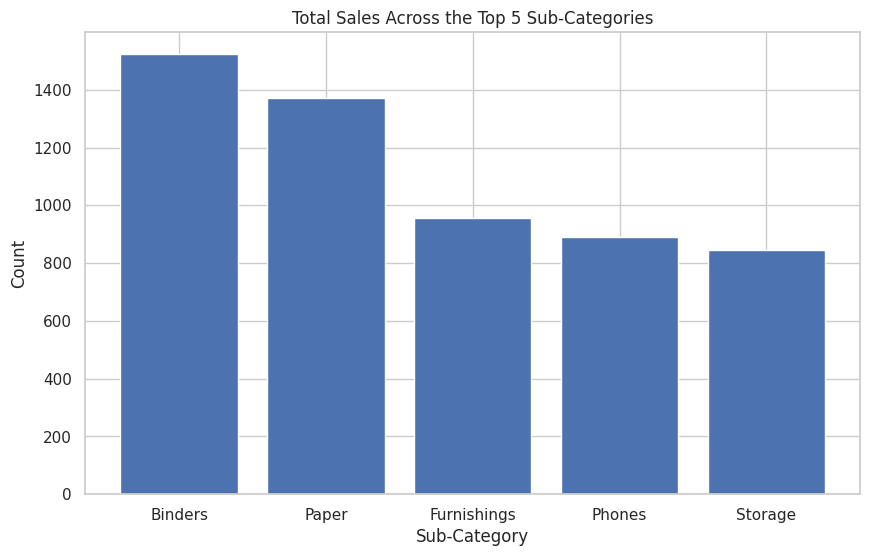

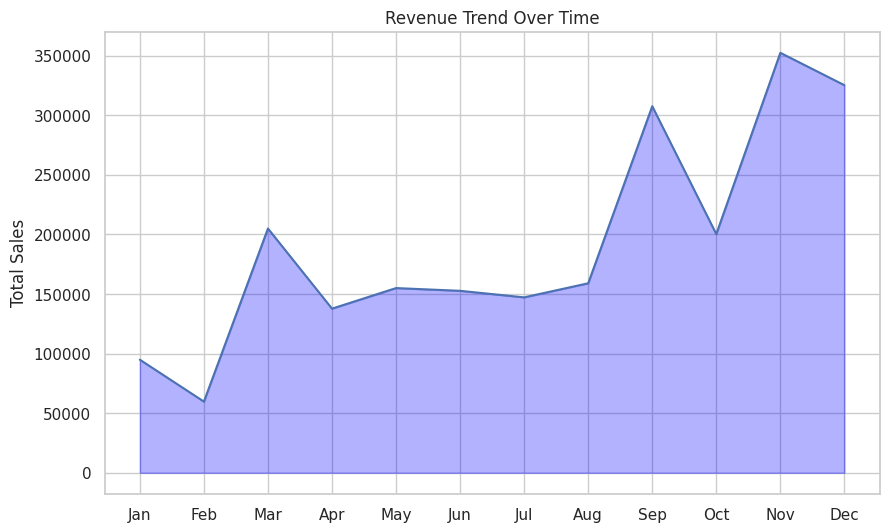

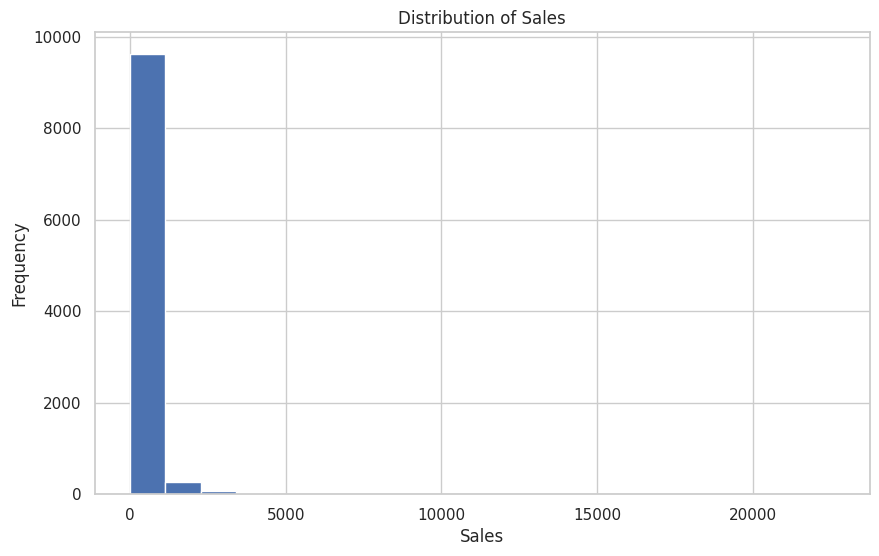

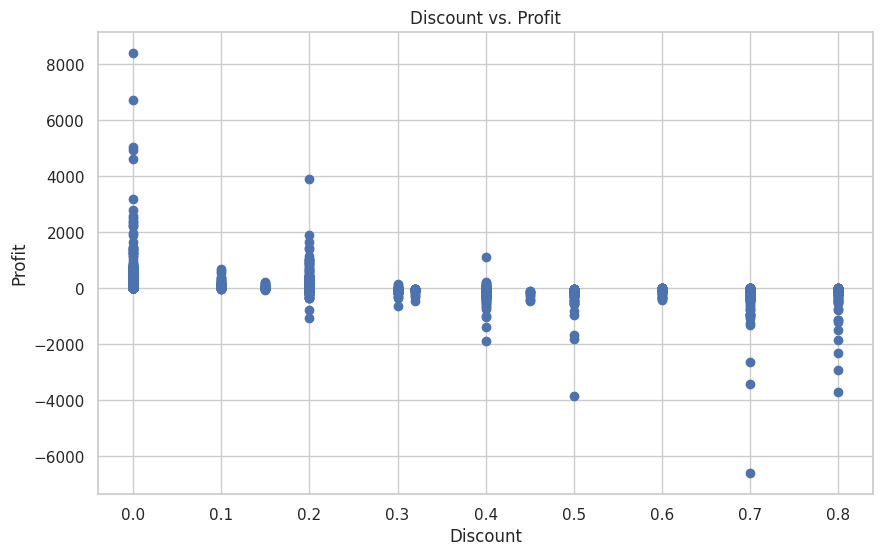

In [ ]:
import matplotlib.pyplot as plt

top5 = df.groupby('Sub-Category').size().sort_values(ascending=False).head(5)


plt.figure(figsize=(10, 6))
plt.bar(top5.index, top5.values)
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.title('Total Sales Across the Top 5 Sub-Categories')

#The bar chart fits because it makes it easy to compare the sales counts across the top 5 sub-categories. A pie chart would be a weaker choice because similar-sized slices are harder to compare accurately and may obscure small differences between sub-categories

plt.figure(figsize=(10,6))
plt.plot(monthly_sales['Month_Num'], monthly_sales['Sales'])
plt.fill_between(monthly_sales['Month_Num'], monthly_sales['Sales'], color='blue', alpha=0.3)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(monthly_sales['Month_Num'], month_names)
plt.ylabel('Total Sales')
plt.title('Revenue Trend Over Time')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=20)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs. Profit')
plt.show()
#

# Task 3

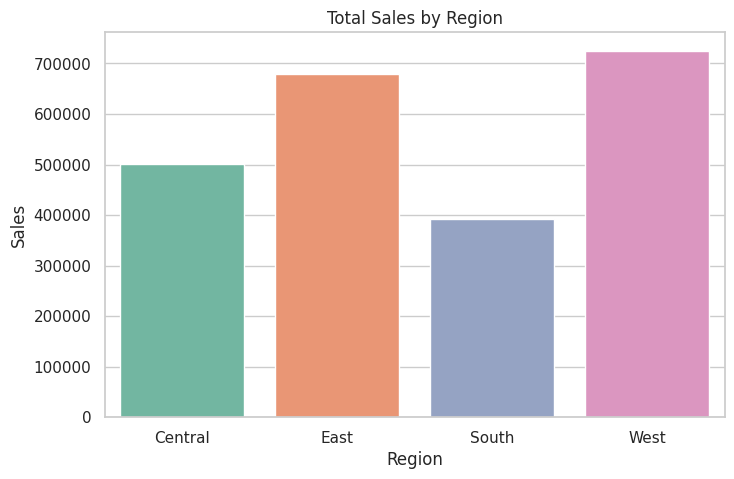

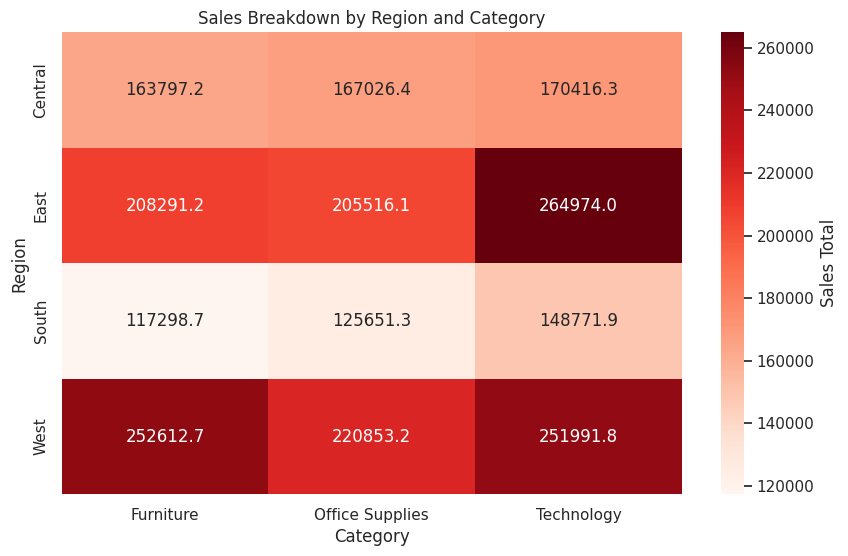

/tmp/ipykernel_2445/3668292365.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_by_month, x='Month_Num', y='Profit', palette=colors)


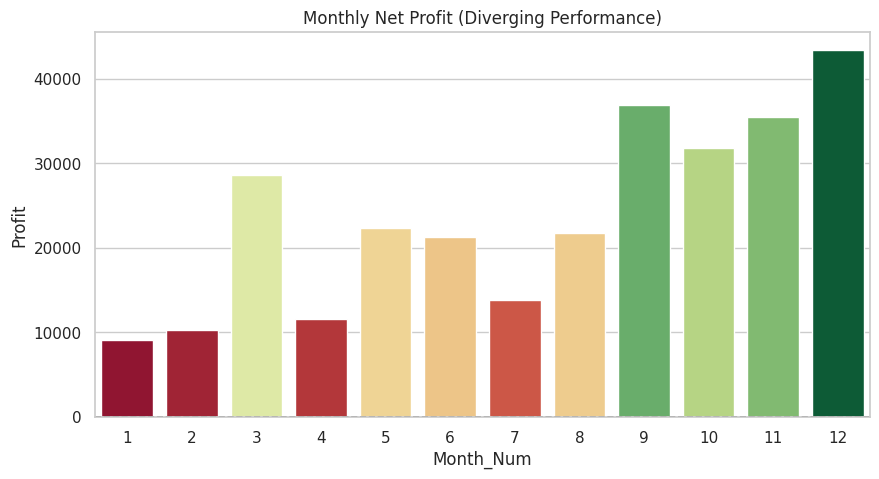

In [ ]:
import pandas as pd
import seaborn as sns


total_sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()

sales_by_region_category = df.groupby(['Region', 'Category'])['Sales'].sum().reset_index()


profit_by_month = df.groupby('Month_Num')['Profit'].sum().reset_index()

sns.set_theme(style="whitegrid")


plt.figure(figsize=(8, 5))
sns.barplot(data=total_sales_by_region, x='Region', y='Sales', hue='Region', palette='Set2', legend=False)
plt.title('Total Sales by Region')
plt.show()


plt.figure(figsize=(10, 6))
heatmap_data = sales_by_region_category.pivot(index='Region', columns='Category', values='Sales')
sns.heatmap(heatmap_data, annot=True,fmt=".1f",cmap='Reds',cbar_kws={'label': 'Sales Total'})
plt.title('Sales Breakdown by Region and Category')
plt.show()


plt.figure(figsize=(10, 5))
profit_by_month = profit_by_month.sort_values('Month_Num')
norm = plt.Normalize(vmin=profit_by_month['Profit'].min(), vmax=profit_by_month['Profit'].max())
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)

colors = [sm.to_rgba(x) for x in profit_by_month['Profit']]

sns.barplot(data=profit_by_month, x='Month_Num', y='Profit', palette=colors)

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.title('Monthly Net Profit (Diverging Performance)')
plt.show()



# Task 4

Red vs White: 4.0 :1
Green vs White: 5.14 :1
Red: FAIL
Green: PASS


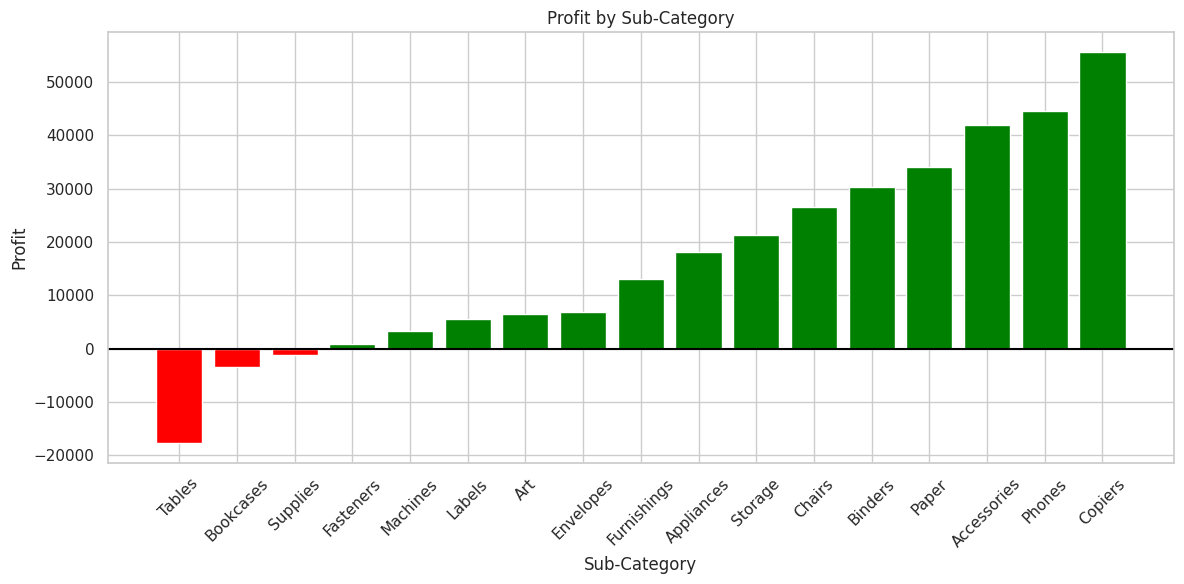

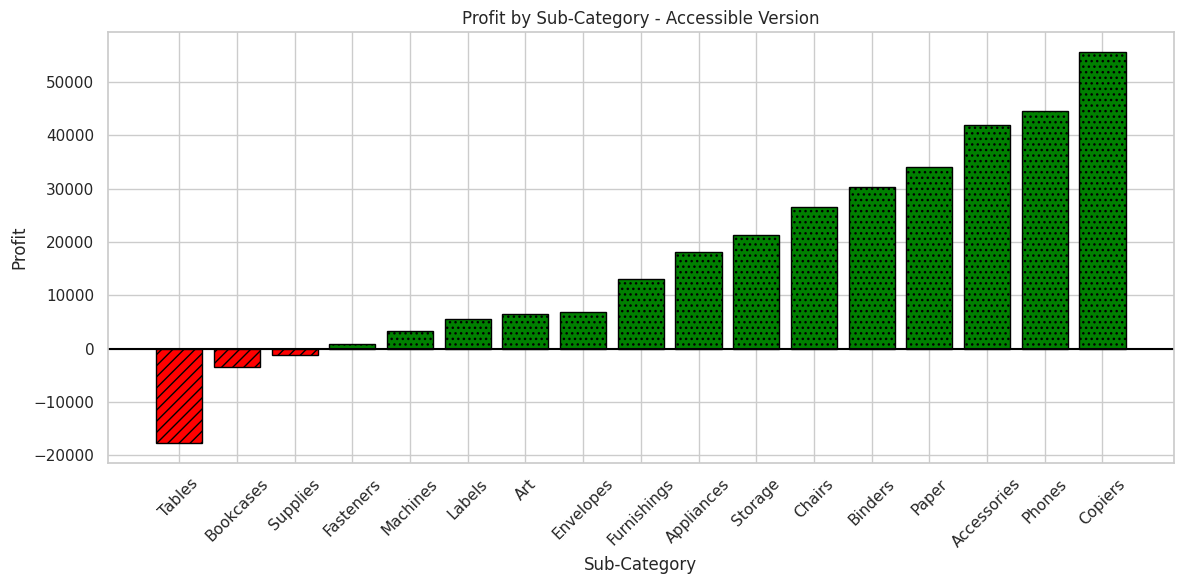

In [ ]:
def contrast_ratio(color1, color2):
    def luminance(color):
        rgb = []

        for value in color:
            value = value / 255

            if value <= 0.03928:
                value = value / 12.92
            else:
                value = ((value + 0.055) / 1.055) ** 2.4

            rgb.append(value)

        return (
            0.2126 * rgb[0]
            + 0.7152 * rgb[1]
            + 0.0722 * rgb[2]
        )

    l1 = luminance(color1)
    l2 = luminance(color2)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)


# Task 3 colors
red = (255, 0, 0)
green = (0, 128, 0)
white = (255, 255, 255)

# Check contrast
red_ratio = contrast_ratio(red, white)
green_ratio = contrast_ratio(green, white)

print("Red vs White:", round(red_ratio, 2), ":1")
print("Green vs White:", round(green_ratio, 2), ":1")

# AA test
if red_ratio >= 4.5:
    print("Red: PASS")
else:
    print("Red: FAIL")

if green_ratio >= 4.5:
    print("Green: PASS")
else:
    print("Green: FAIL")



import matplotlib.pyplot as plt
import pandas as pd

profit_by_subcategory = (df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values('Profit'))


colors = ['red' if profit < 0 else 'green'
for profit in profit_by_subcategory['Profit']]

plt.figure(figsize=(12, 6))

plt.bar(profit_by_subcategory['Sub-Category'],profit_by_subcategory['Profit'],color=colors)

plt.axhline(0, color='black')

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




plt.figure(figsize=(12, 6))

for subcategory, profit in zip(profit_by_subcategory['Sub-Category'],profit_by_subcategory['Profit']):

    if profit < 0:
        plt.bar(subcategory,profit,color='red',hatch='///',edgecolor='black')
    else:
        plt.bar(subcategory,profit,color='green',hatch='...',edgecolor='black')

plt.axhline(0, color='black')

plt.title('Profit by Sub-Category - Accessible Version')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





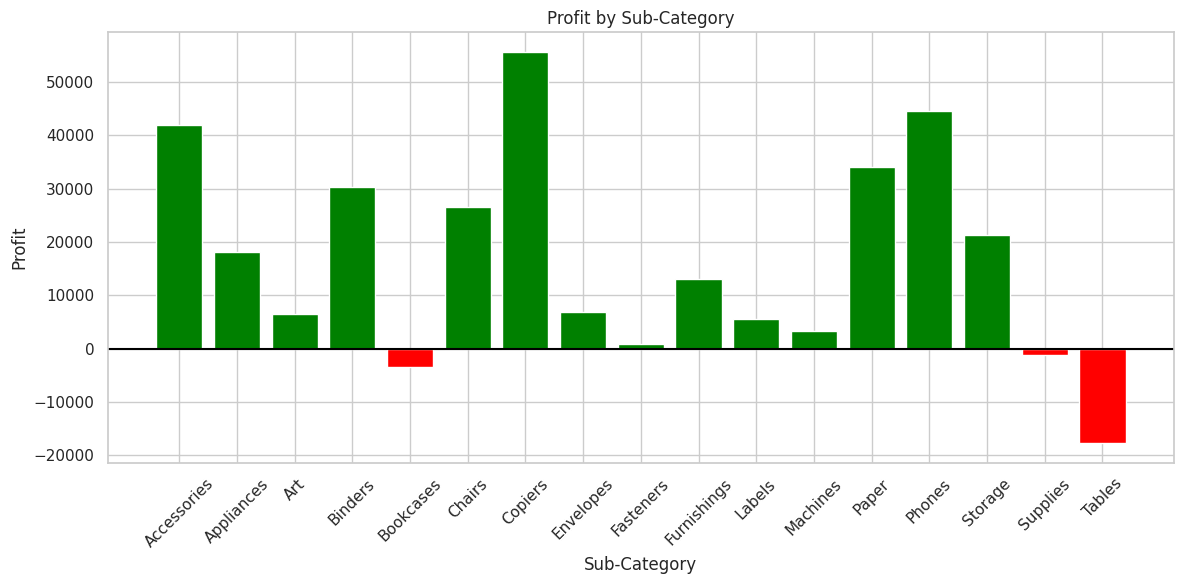

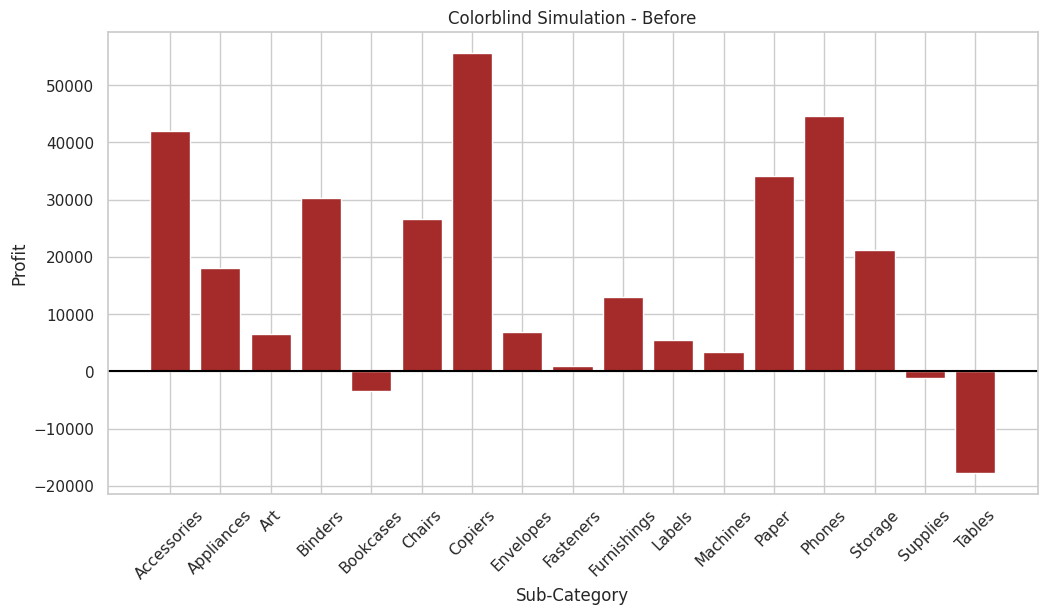

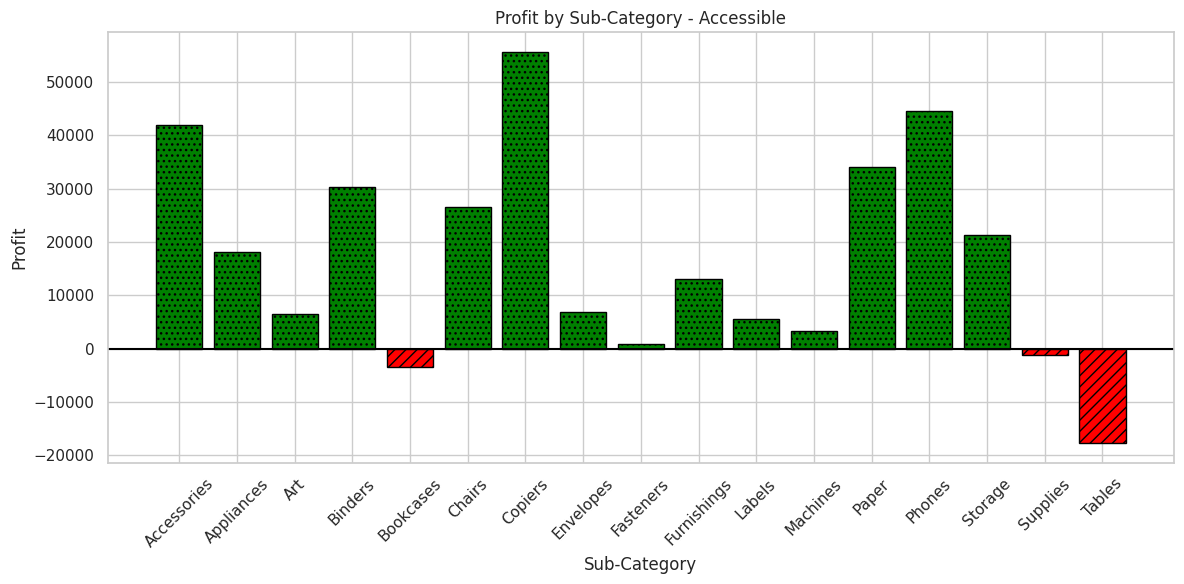

In [ ]:
import matplotlib.pyplot as plt

profit = df.groupby('Sub-Category')['Profit'].sum()


colors = ['red' if x < 0 else 'green' for x in profit]

plt.figure(figsize=(12, 6))

plt.bar(profit.index, profit.values, color=colors)

plt.axhline(0, color='black')
plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('before.png')
plt.show()

simulated_colors = [
    'brown' if x < 0 else 'brown'
    for x in profit]

plt.figure(figsize=(12, 6))

plt.bar(profit.index, profit.values, color=simulated_colors)

plt.axhline(0, color='black')
plt.title('Colorblind Simulation - Before')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(12, 6))

for name, value in profit.items():

    if value < 0:
        plt.bar(name,value,color='red',hatch='///', edgecolor='black')
    else:
        plt.bar(name,value,color='green', hatch='...',edgecolor='black')

plt.axhline(0, color='black')
plt.title('Profit by Sub-Category - Accessible')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('after.png')
plt.show()


# Task 5

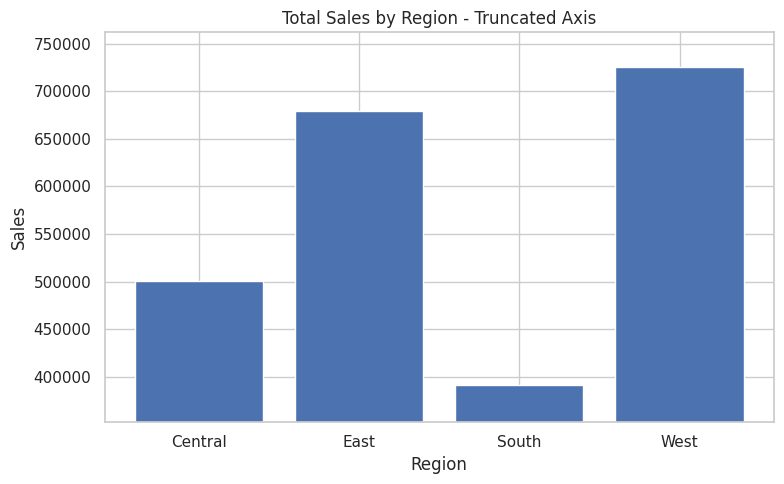

Truncated y-axis starts above zero, exaggerating the apparent differences between regional sales.


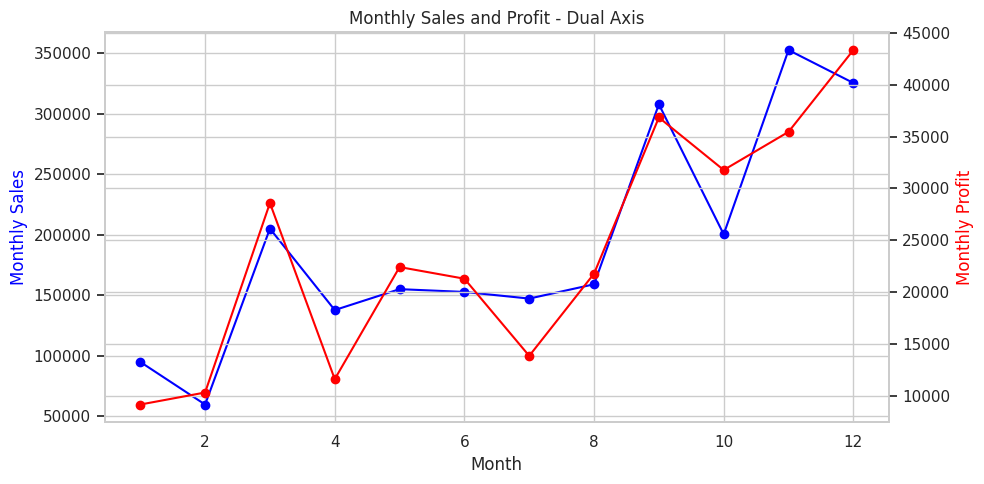

Dual y-axes overlay sales and profit on different scales, which can imply a stronger correlation than exists.


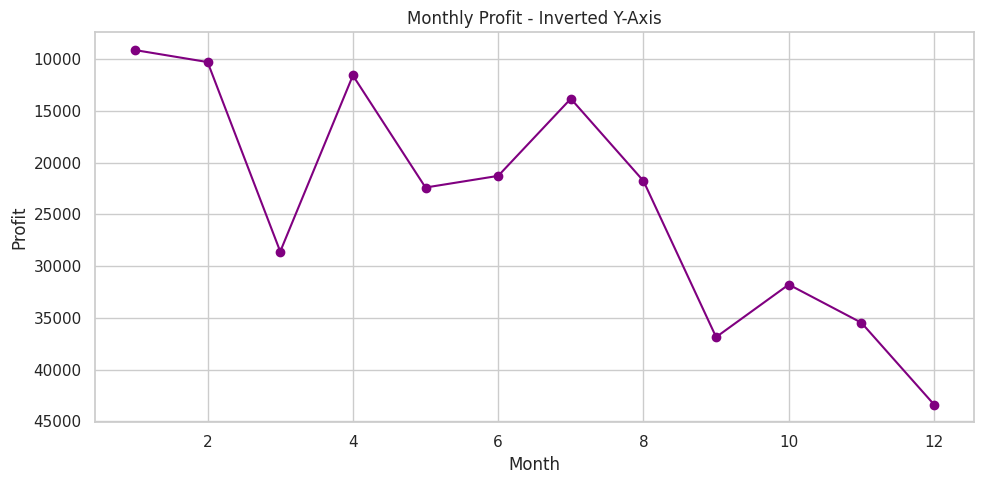

Inverted y-axis reverses the normal visual direction, making increases appear visually downward and decreases upward.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Num'] = df['Order Date'].dt.month

total_sales_by_region = (df.groupby('Region')['Sales'].sum().reset_index())

monthly_sales = (df.groupby('Month_Num')['Sales'].sum().reset_index())

profit_by_month = (
    df.groupby('Month_Num')['Profit']
    .sum()
    .reset_index()
)

sns.set_theme(style="whitegrid")


plt.figure(figsize=(8, 5))

plt.bar(
    total_sales_by_region['Region'],
    total_sales_by_region['Sales']
)

plt.ylim(
    total_sales_by_region['Sales'].min() * 0.9,
    total_sales_by_region['Sales'].max() * 1.05
)

plt.title('Total Sales by Region - Truncated Axis')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

print("Truncated y-axis starts above zero, exaggerating the apparent differences between regional sales.")


fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(monthly_sales['Month_Num'],monthly_sales['Sales'],color='blue',marker='o')

ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Sales', color='blue')

ax2 = ax1.twinx()

ax2.plot(profit_by_month['Month_Num'],profit_by_month['Profit'],color='red', marker='o')

ax2.set_ylabel('Monthly Profit', color='red')

plt.title('Monthly Sales and Profit - Dual Axis')
plt.tight_layout()
plt.show()

print("Dual y-axes overlay sales and profit on different scales, which can imply a stronger correlation than exists.")


plt.figure(figsize=(10, 5))

plt.plot(profit_by_month['Month_Num'], profit_by_month['Profit'],marker='o',color='purple')

plt.gca().invert_yaxis()

plt.title('Monthly Profit - Inverted Y-Axis')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

print("Inverted y-axis reverses the normal visual direction, making increases appear visually downward and decreases upward.")

# Task 6

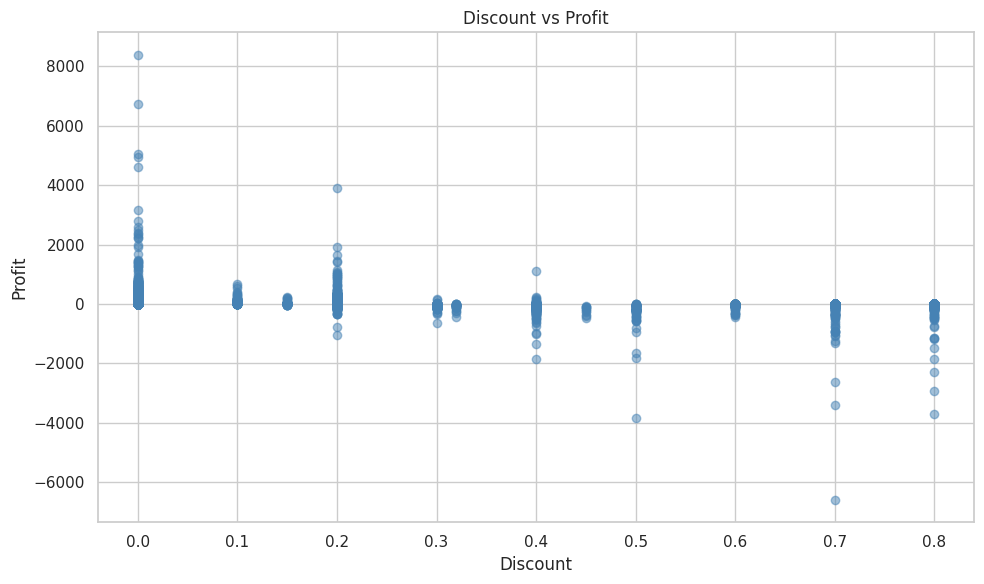

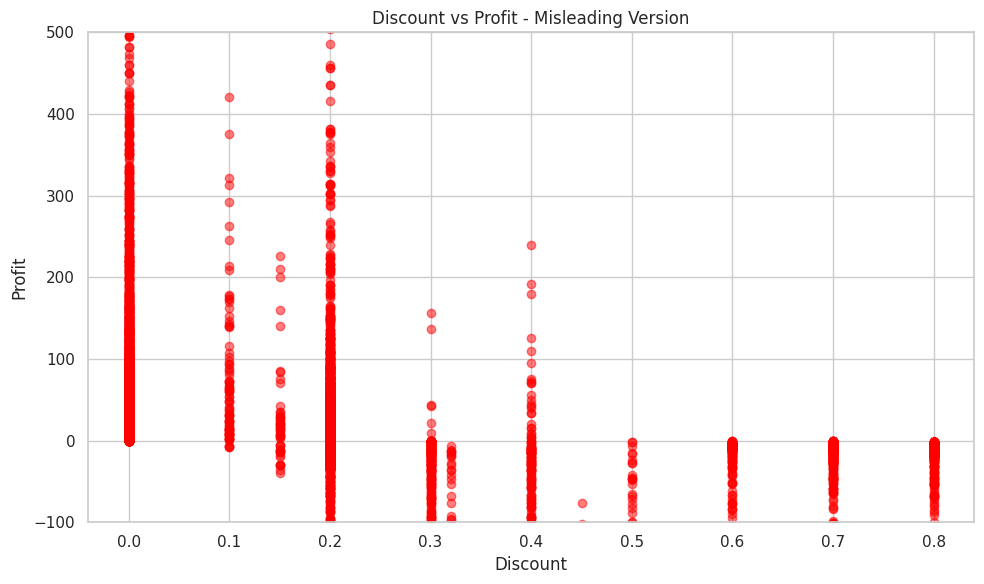

The honest chart uses blue points on a white background.
The chart does not rely on red/green color differences.
An alpha value is used to reduce overlap between points.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Is discounting hurting profit?


plt.figure(figsize=(10, 6))

plt.scatter(df['Discount'],df['Profit'],alpha=0.5,color='steelblue')


plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')

plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

plt.scatter(df['Discount'],df['Profit'],alpha=0.5,color='red')


plt.ylim(-100, 500)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit - Misleading Version')

plt.tight_layout()
plt.show()

print("The honest chart uses blue points on a white background.")
print("The chart does not rely on red/green color differences.")
print("An alpha value is used to reduce overlap between points.")


**Chart type:** I used a scatter plot because both discount and profit are numeric variables. A scatter plot allows us to see the relationship and whether higher discounts tend to be associated with lower profit.

**Honest Char** The honest version shows the full range of the data without manipulating the axis, so the relationship can be judged fairly.

**Misleading chart**: The misleading version restricts the y-axis to -100 to 500, hiding observations outside that range and potentially making the relationship appear stronger than it really is.

**Color**: I used blue for the honest chart because it is easy to distinguish from the white background and does not depend on red/green perception.

**Accessibility**: The chart does not rely on color alone to communicate the relationship. The points, axes, labels, and zero-profit line provide the information. The blue-on-white contrast should also be checked against the WCAG 4.5:1 threshold if the exact colors are retained.